# B21 — Deutsch–Jozsa and Bernstein–Vazirani in Qiskit

**Track B — the SDK.** A09 built these two algorithms out of NumPy matrices: a
$2^n \times 2^n$ diagonal of $\pm1$ for the phase oracle, a $2^{n+1}$-square
permutation for the XOR oracle. Both were *written down entry by entry*, which is
exactly what a real machine cannot do.

Here the oracle is a **circuit**. That single change is the whole point of this
notebook, and it is where the algorithm's famous headline starts to wobble.

---

## The one-sentence version

You are handed a black box computing some $f$ of an $n$-bit input, promised it is
either **constant** or **balanced**. Classically, being *certain* costs
$2^{n-1}+1$ queries in the worst case. Quantumly it costs **one** — and in this
notebook that "one" is a circuit you can look at, transpile, and count the gates
of.

## Where the SDK changes the story

A09 could say "the oracle is a matrix, here it is". Qiskit cannot hand you a
$2^{20}$-square matrix, and neither can a fridge. So the first question the SDK
forces on you is: *what does the box look like as gates?* Three answers appear
below, and they are wildly different in cost:

| oracle | as a circuit | cost |
|---|---|---|
| Bernstein–Vazirani, secret $s$ | one `cx` per set bit of $s$ | **$n$ gates** |
| $f(x) = x_0$, parity, constants | one or zero gates | trivial |
| an arbitrary balanced $f$ given as a truth table | one multi-controlled gate **per input where $f = 1$** | **$2^{n-1}$ blocks** |

The last row is the honest one, and Figure 6 measures it with `transpile()`. The
"one query" is real. The query is not free.

## What Track A already gave us

| A09 | here |
|---|---|
| `phase_oracle(f, n)` — a diagonal of $\pm1$ | `phase_oracle_circuit(f, n)` — multi-controlled phases |
| `xor_oracle(f, n)` — a permutation matrix | `xor_oracle_circuit(f, n)` — `mcx` onto an ancilla |
| kickback verified as `U @ kron(MINUS, psi) == kron(MINUS, D @ psi)` | the same identity, on `Statevector` |
| "measure once, read the answer" | `SamplerV2` with **`shots=1`** |
| the 70 balanced functions on 3 bits | the same 70, as 70 executed circuits |

The checkpoint at the bottom rebuilds A09's `dj_stages` in raw NumPy and asserts
`np.allclose` against every statevector Qiskit produced along the way.

## One trap, flagged before we hit it

CLAUDE.md §2: **Aer cannot execute an anonymous controlled subcircuit.**
`oracle.to_gate().control(1)` builds a perfectly correct `Operator` and then dies
inside a primitive with `AerError: unknown instruction: ccircuit-NNN`. We never
do that. Oracles are composed as plain circuits with `qc.compose(...)`, and
anything multi-controlled goes through `transpile()` before it reaches
`SamplerV2`. Both habits are visible in the code below.

In [1]:
from qviz import backends, grid, style

from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Operator, Statevector

style.use()

SEED = backends.seed_for("B21")
rng = np.random.default_rng(SEED)
BACKEND = backends.get_backend()

print("qiskit", qiskit.__version__, " seed", SEED)
print("backend:", BACKEND.name)

qiskit 2.5.1  seed 20260825
backend: aer_simulator


---

## Part 1 — an oracle, as gates

A09's two oracle forms, restated as circuit constructions.

**The XOR (or *standard*) oracle** keeps the input and writes the answer onto an
ancilla:

$$U_f\,|x\rangle_{\text{in}}|y\rangle_{\text{anc}} = |x\rangle\,|y \oplus f(x)\rangle.$$

As a circuit: for every input $x$ with $f(x)=1$, flip the ancilla *conditioned on
the register holding exactly $x$*. "Conditioned on exactly $x$" is an `mcx` with
$X$ gates wrapped around whichever control qubits should be $0$ — the standard
trick for turning a multi-controlled gate that fires on $|1\cdots1\rangle$ into
one that fires on $|x\rangle$.

**The phase oracle** is what you get after kickback, on the $n$ input qubits
alone:

$$D_f = \mathrm{diag}\big((-1)^{f(x)}\big).$$

Same construction with `mcp(pi, ...)` instead of `mcx` — a multi-controlled
$\pi$-phase is exactly $I - 2|1\cdots1\rangle\langle1\cdots1|$, and conjugating by
$X$s moves the marked corner to $|x\rangle$.

Both loops run over all $2^n$ inputs and call `f` on each one. **That loop is
$2^n$ classical queries**, which is the same accounting problem A09 flagged: the
generic construction of the box costs more than the box saves. Real oracles are
never built this way — they are *compiled from structure*, which is why the
Bernstein–Vazirani oracle below is $n$ gates rather than $2^{n-1}$ blocks.

### Endianness, once

Qubit $q$ carries bit $q$ of the input index, and qubit 0 is the **rightmost**
character of every printed label. `mcp` on qubits $0..n-1$ marks the index whose
bits are all 1. The ancilla lives on qubit $n$ — the highest index, hence the
leftmost label character and the *first* `np.kron` factor. Exactly A09's layout,
asserted rather than assumed.

In [2]:
def label(i, n):
    """Printed bitstring for index i: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


def bit(x, q):
    """Bit q of integer x, little-endian."""
    return (x >> q) & 1


def parity(v):
    """1 if v has an odd number of set bits."""
    return bin(v).count("1") & 1


def _zeros_of(x, n):
    return [q for q in range(n) if not bit(x, q)]


def phase_oracle_circuit(f, n, name="D_f"):
    """D_f = diag((-1)^f(x)) as a circuit on n qubits.

    One multi-controlled pi-phase per input where f(x) = 1, conjugated by X on
    that input's zero bits. mcp is a LIBRARY instruction (MCPhaseGate), so it
    transpiles; an anonymous `.to_gate().control(k)` would not survive Aer.
    """
    qc = QuantumCircuit(n, name=name)
    for x in range(2 ** n):
        if f(x):
            zeros = _zeros_of(x, n)
            for q in zeros:
                qc.x(q)
            if n == 1:
                qc.z(0)
            else:
                qc.mcp(np.pi, list(range(n - 1)), n - 1)
            for q in zeros:
                qc.x(q)
    return qc


def xor_oracle_circuit(f, n, name="U_f"):
    """U_f |x>|y> = |x>|y xor f(x)>, ancilla on qubit n."""
    qc = QuantumCircuit(n + 1, name=name)
    for x in range(2 ** n):
        if f(x):
            zeros = _zeros_of(x, n)
            for q in zeros:
                qc.x(q)
            qc.mcx(list(range(n)), n)
            for q in zeros:
                qc.x(q)
    return qc


# --- the structured forms: what a compiler would actually emit ---------------
def bv_f(s):
    """f_s(x) = s . x mod 2."""
    return lambda x, s=s: parity(s & x)


def bv_phase_circuit(s, n):
    """The BV phase oracle: a Z on every qubit where the secret has a 1."""
    qc = QuantumCircuit(n, name="D_s")
    for q in range(n):
        if bit(s, q):
            qc.z(q)
    return qc


def bv_xor_circuit(s, n):
    """The BV XOR oracle: a CX from every secret bit onto the ancilla."""
    qc = QuantumCircuit(n + 1, name="U_s")
    for q in range(n):
        if bit(s, q):
            qc.cx(q, n)
    return qc


# The two constructions must agree - one built from the truth table, one from
# the structure. This is the "compiler got it right" check.
for n in (2, 3, 4):
    for s in range(2 ** n):
        assert np.allclose(Operator(phase_oracle_circuit(bv_f(s), n)).data,
                           Operator(bv_phase_circuit(s, n)).data), (n, s)
        assert np.allclose(Operator(xor_oracle_circuit(bv_f(s), n)).data,
                           Operator(bv_xor_circuit(s, n)).data), (n, s)
print("truth-table construction == structured construction, all secrets n = 2,3,4")

# Endianness, asserted: Z on qubit 0 must put -1 on the ODD indices.
d = np.diag(Operator(bv_phase_circuit(0b0001, 3)).data).real
print("\ndiag of the s=001 phase oracle:", np.round(d, 6).astype(int))
assert np.allclose(d, [(-1.0) ** bit(x, 0) for x in range(8)])

print("\ns = 1011 as gates:")
print(bv_xor_circuit(0b1011, 4))

truth-table construction == structured construction, all secrets n = 2,3,4

diag of the s=001 phase oracle: [ 1 -1  1 -1  1 -1  1 -1]

s = 1011 as gates:
                    
q_0: ──■────────────
       │            
q_1: ──┼────■───────
       │    │       
q_2: ──┼────┼───────
       │    │       
q_3: ──┼────┼────■──
     ┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├┤ X ├
     └───┘└───┘└───┘


Three `cx` gates. That is the entire Bernstein–Vazirani oracle for a 4-bit
secret, and it stays three-ish gates — one per set bit — forever. Compare that
with `phase_oracle_circuit`, which for the same function walks all 16 inputs and
emits a multi-controlled phase for each of the 8 where $f=1$. Same unitary,
asserted above; wildly different circuits. **Structure is the whole game.**

### Kickback, on a `Statevector`

A09 proved $U_f(|x\rangle \otimes |-\rangle) = (-1)^{f(x)}|x\rangle \otimes
|-\rangle$ as a matrix identity. Here it is on actual circuit output. Note the
`np.kron(minus, psi)` ordering: the ancilla is the **highest** qubit, so it is the
**first** Kronecker factor. Getting that backwards is the classic bug, and it
produces a state that is wrong but normalised, so nothing complains.

In [3]:
MINUS = np.array([1, -1], dtype=complex) / np.sqrt(2)


def hadamard_all_np(n):
    """H^(x)n as a raw NumPy matrix -- the A09 helper, reused for cross-checks."""
    H1 = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
    out = np.array([[1.0 + 0j]])
    for _ in range(n):
        out = np.kron(out, H1)
    return out


def kickback_circuit(xor_oracle, n):
    """|+...+> on the input, |-> on the ancilla, then the XOR oracle."""
    qc = QuantumCircuit(n + 1)
    qc.x(n)
    qc.h(n)                       # ancilla -> |->
    qc.h(list(range(n)))          # inputs  -> uniform superposition
    qc.compose(xor_oracle, qubits=list(range(n + 1)), inplace=True)
    return qc


N_DEMO = 3
f_demo = lambda x: (x * x + 1) % 2

joint = Statevector(kickback_circuit(xor_oracle_circuit(f_demo, N_DEMO),
                                     N_DEMO)).data
e0 = np.zeros(2 ** N_DEMO, dtype=complex); e0[0] = 1.0
uniform = hadamard_all_np(N_DEMO) @ e0
signed = np.array([(-1.0) ** f_demo(x) for x in range(2 ** N_DEMO)]) * uniform

print("U_f (|+...+> (x) |->)  ==  ((-1)^f(x) on the inputs) (x) |-> :",
      np.allclose(joint, np.kron(MINUS, signed)))

# The ancilla really is a catalyst: reshape so rows index the ancilla value.
anc = joint.reshape(2, 2 ** N_DEMO)
print("  ancilla |0> component norm:", f"{np.linalg.norm(anc[0]):.6f}")
print("  ancilla |1> component norm:", f"{np.linalg.norm(anc[1]):.6f}")
print("  still exactly |-> ?        ", np.allclose(anc[1], -anc[0]))

# ...and the n-qubit phase oracle reproduces the input register on its own,
# with no ancilla anywhere. That is why every figure below drops it.
qc_phase = QuantumCircuit(N_DEMO)
qc_phase.h(list(range(N_DEMO)))
qc_phase.compose(phase_oracle_circuit(f_demo, N_DEMO), inplace=True)
print("\nn-qubit phase oracle reproduces the same signs:",
      np.allclose(Statevector(qc_phase).data, signed))

U_f (|+...+> (x) |->)  ==  ((-1)^f(x) on the inputs) (x) |-> : True
  ancilla |0> component norm: 0.707107
  ancilla |1> component norm: 0.707107
  still exactly |-> ?         True

n-qubit phase oracle reproduces the same signs: True


## Figure 1 — the same five oracles, three ways

A09's Figure 1 drew an oracle as what it *means*: a $\pm1$ label on each of the 16
four-bit inputs. Qiskit lets us put that picture next to what a machine actually
runs.

- **Top row** — the XOR oracle on 5 qubits (4 input + 1 ancilla). This is the form
  hardware executes.
- **Middle row** — the phase oracle on the 4 input qubits alone, after kickback
  has been done in your head. `constant 0` is *literally nothing*; `constant 1` is
  a **global phase**, which is to say also nothing you could ever detect. Both
  land on $|0000\rangle$, and Deutsch–Jozsa says "constant" without being able to
  tell you *which* constant. That limitation is invisible in the matrix picture
  and obvious here.
- **Bottom row** — A09's sign grid, rows = high bits $q_3q_2$, columns = low bits
  $q_1q_0$, warm $=+1$, teal $=-1$, straight off the repo's phase wheel.

Read a column top to bottom and you get the same object three times. The last two
oracles are both Bernstein–Vazirani in disguise: $f(x)=x_0$ is $s=0001$ and parity
is $s=1111$.

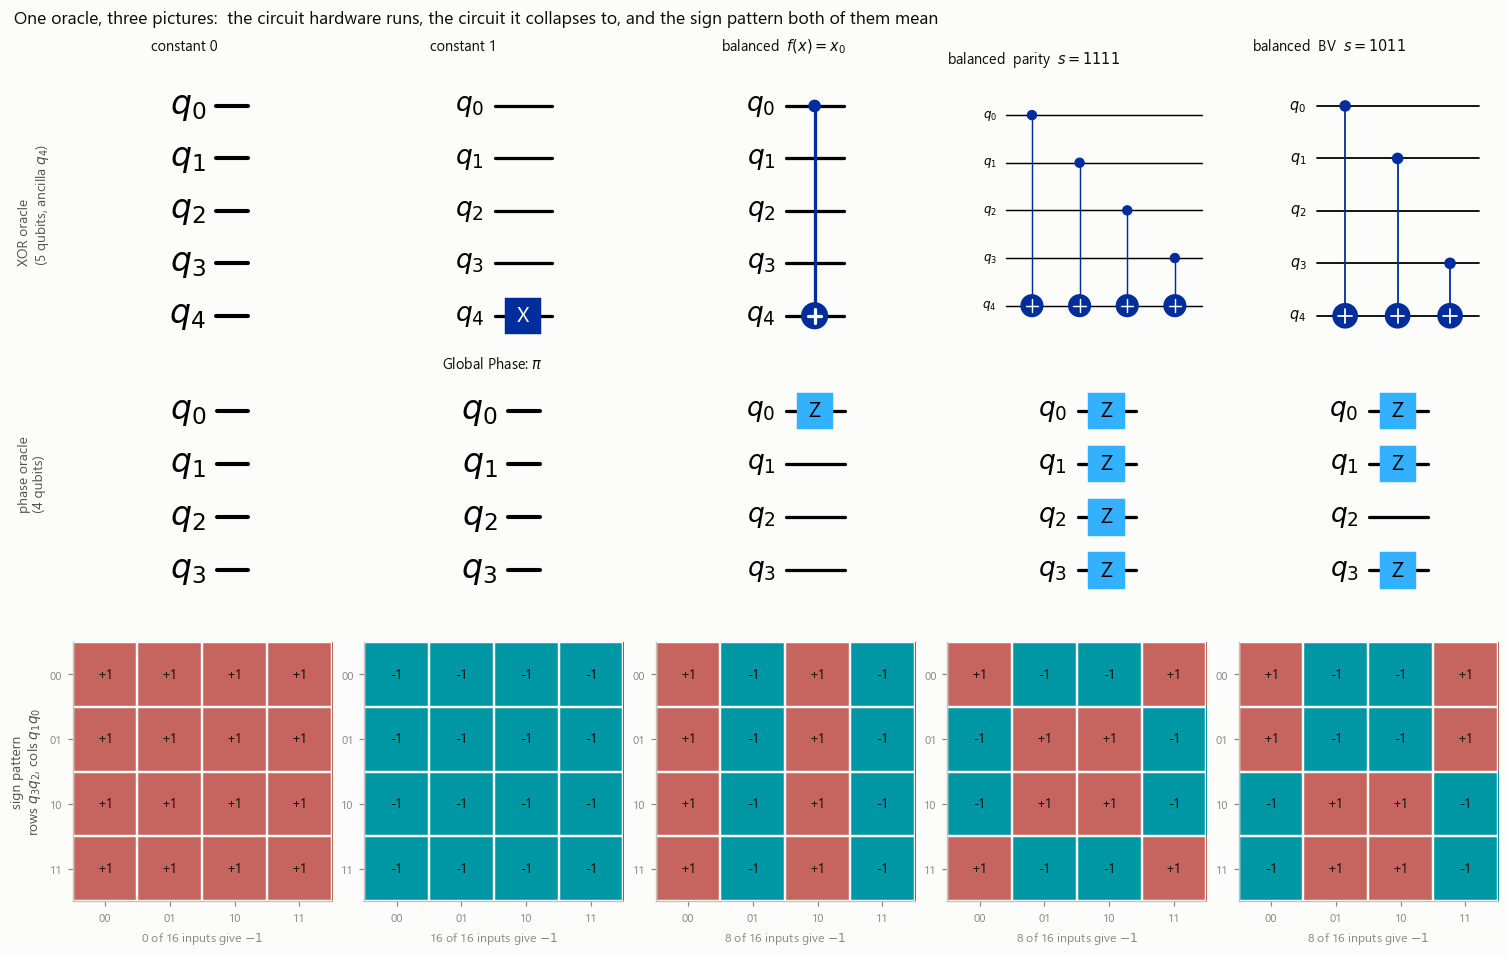

  constant 0                   sum of signs = +16   average = +1.000   xor gates = 0
  constant 1                   sum of signs = -16   average = -1.000   xor gates = 1
  balanced f(x)=x_0            sum of signs =  +0   average = +0.000   xor gates = 1
  balanced parity s=1111       sum of signs =  +0   average = +0.000   xor gates = 4
  balanced BV s=1011           sum of signs =  +0   average = +0.000   xor gates = 3


In [4]:
from matplotlib.colors import ListedColormap

N_BITS = 4
N_IN = 2 ** N_BITS
SIGN_CMAP = ListedColormap([style.PHASE(0.0), style.PHASE(0.5)])

# Structured circuits only -- the truth-table construction for `constant 1` is
# sixteen CCCZ blocks and would draw as a black smear. They are the same
# unitary; the assertion in the checkpoint proves it.
const0_xor = QuantumCircuit(N_BITS + 1)
const1_xor = QuantumCircuit(N_BITS + 1)
const1_xor.x(N_BITS)
const0_phase = QuantumCircuit(N_BITS)
const1_phase = QuantumCircuit(N_BITS)
const1_phase.global_phase = np.pi          # -I: undetectable, and that is the point

DISPLAY = [
    ("constant 0", lambda x: 0, const0_xor, const0_phase),
    ("constant 1", lambda x: 1, const1_xor, const1_phase),
    (r"balanced  $f(x)=x_0$", lambda x: bit(x, 0),
     bv_xor_circuit(0b0001, N_BITS), bv_phase_circuit(0b0001, N_BITS)),
    (r"balanced  parity  $s=1111$", parity,
     bv_xor_circuit(0b1111, N_BITS), bv_phase_circuit(0b1111, N_BITS)),
    (r"balanced  BV  $s=1011$", bv_f(0b1011),
     bv_xor_circuit(0b1011, N_BITS), bv_phase_circuit(0b1011, N_BITS)),
]

fig = plt.figure(figsize=(13.6, 8.6))
gs = fig.add_gridspec(3, 5, height_ratios=[1.15, 0.95, 1.30])

for k, (name, f, xor_c, ph_c) in enumerate(DISPLAY):
    axa = fig.add_subplot(gs[0, k])
    xor_c.draw("mpl", ax=axa, style={"backgroundcolor": style.SURFACE})
    axa.set_title(name, loc="left", fontsize=9.5)

    axb = fig.add_subplot(gs[1, k])
    ph_c.draw("mpl", ax=axb, style={"backgroundcolor": style.SURFACE})

    axc = fig.add_subplot(gs[2, k])
    G = np.array([[f((r << 2) | c) for c in range(4)] for r in range(4)])
    axc.imshow(G, cmap=SIGN_CMAP, vmin=0, vmax=1, interpolation="nearest")
    for r in range(4):
        for c in range(4):
            axc.text(c, r, "+1" if G[r, c] == 0 else "-1", ha="center",
                     va="center", fontsize=8.5, color=style.INK)
    axc.set_xticks(range(4)); axc.set_yticks(range(4))
    axc.set_xticklabels(["00", "01", "10", "11"], fontsize=7.5)
    axc.set_yticklabels(["00", "01", "10", "11"], fontsize=7.5)
    axc.set_xticks(np.arange(-0.5, 4, 1), minor=True)
    axc.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    axc.grid(which="minor", color=style.SURFACE, linewidth=1.6)
    axc.grid(which="major", visible=False)
    axc.tick_params(which="minor", length=0)
    axc.set_xlabel(f"{int(G.sum())} of 16 inputs give $-1$", fontsize=8,
                   color=style.MUTED)

# The circuit drawer turns its axes off, so those two rows cannot carry a
# y-label. Name them on the figure instead, at the same x as the third row's.
fig.text(0.008, 0.79, "XOR oracle\n(5 qubits, ancilla $q_4$)", rotation=90,
         ha="left", va="center", fontsize=9, color=style.INK_2)
fig.text(0.008, 0.505, "phase oracle\n(4 qubits)", rotation=90,
         ha="left", va="center", fontsize=9, color=style.INK_2)
fig.axes[2].set_ylabel("sign pattern\nrows $q_3q_2$, cols $q_1q_0$",
                       fontsize=9, color=style.INK_2)

fig.suptitle("One oracle, three pictures:  the circuit hardware runs, the circuit "
             "it collapses to, and the sign pattern both of them mean",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

for name, f, xor_c, ph_c in DISPLAY:
    s = sum((-1) ** f(x) for x in range(N_IN))
    plain = (name.replace("$", "").replace("\\", "")
             .replace("  ", " ").strip())
    print(f"  {plain:<28} sum of signs = {s:+3d}   average = {s / N_IN:+.3f}"
          f"   xor gates = {sum(xor_c.count_ops().values())}")

That last column of numbers is the algorithm. The amplitude Deutsch–Jozsa leaves
on $|0000\rangle$ is the **average sign** $\frac{1}{2^n}\sum_x(-1)^{f(x)}$:
exactly $\pm1$ when the signs all agree, exactly $0$ when they cancel in matched
pairs. No approximation, no statistics.

And note the middle row of the figure once more. The phase oracle for
`constant 0` has no gates at all, and the one for `constant 1` is a global phase.
Deutsch–Jozsa's answer for both is $|0000\rangle$ with probability 1 — the
algorithm cannot distinguish them, and no algorithm can, because on the input
register they are the *same unitary up to a global phase*. It was never asked to;
the question was "constant or balanced".

## Figure 2 — the filmstrip, from `Statevector`

A09's Figure 2, rebuilt out of Qiskit objects. Each column is
`Statevector(prefix_circuit)` for a longer and longer prefix of the same circuit:

$$|000\rangle
\;\xrightarrow{\;H^{\otimes3}\;}\;
\tfrac{1}{\sqrt8}\textstyle\sum_x |x\rangle
\;\xrightarrow{\;D_f\;}\;
\tfrac{1}{\sqrt8}\textstyle\sum_x (-1)^{f(x)}|x\rangle
\;\xrightarrow{\;H^{\otimes3}\;}\;
\textstyle\sum_y \big(\tfrac{1}{8}\sum_x (-1)^{f(x)+x\cdot y}\big)|y\rangle.$$

Top row constant, bottom row balanced; the **only** difference is the sign
pattern in column 3. Three things to watch, exactly as in A09:

1. **Column 2 is identical in both rows.** The register knows nothing yet.
2. **Column 3 changes no bar heights.** A diagonal of $\pm1$ cannot move
   probability, only recolour it. Measure here and you get a uniform random
   3-bit string either way.
3. **Column 4 is where the physics happens.** The final Hadamard layer sums the
   eight amplitudes with signs $(-1)^{x\cdot y}$; the balanced case cancels to
   exactly zero at $y = 000$.

Column 5 is the Track B addition A09 could not have: **`SamplerV2` counts** from
the 4-qubit ancilla circuit, the one a machine would run, with the exact
probabilities drawn on top as ticks. Note the classical register is named `"c"`,
so the counts come out of `result[k].data.c` — the V2 result-access trap from
CLAUDE.md §2. `measure_all()` would have called it `meas`.

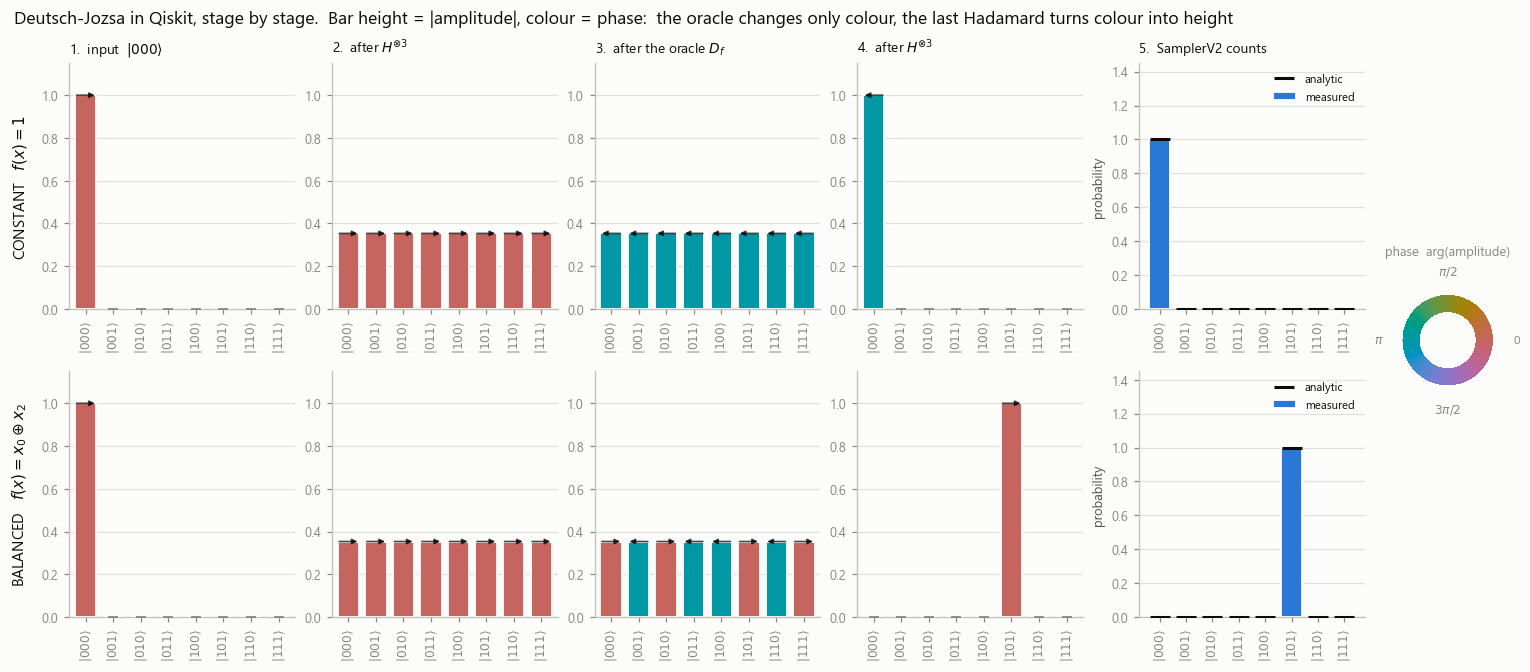

CONSTANT  amplitude on |000> = -1.000000000000000   P = 0.999999999999999   sampled 4096/4096 shots on |000>
BALANCED  amplitude on |000> = +0.000000000000000   P = 0.000000000000000   sampled 0/4096 shots on |000>


In [5]:
N_DJ = 3
DIM_DJ = 2 ** N_DJ
SHOTS = 4096


def dj_prefix(phase_oracle, n, upto):
    """Prefix of the phase-oracle Deutsch-Jozsa circuit, for statevector taps."""
    qc = QuantumCircuit(n)
    if upto >= 1:
        qc.h(list(range(n)))
    if upto >= 2:
        qc.compose(phase_oracle, inplace=True)
    if upto >= 3:
        qc.h(list(range(n)))
    return qc


def dj_stages_qk(phase_oracle, n):
    """The four statevectors of a run, straight out of qiskit.quantum_info."""
    return [Statevector(dj_prefix(phase_oracle, n, k)).data for k in range(4)]


def dj_measured(xor_oracle, n):
    """The full circuit a machine runs: ancilla in |->, oracle, H layer, measure.

    An explicit ClassicalRegister named "c" -- the repo standard, so results come
    out of `.data.c` rather than `.data.meas`.
    """
    qr, cr = QuantumRegister(n + 1, "q"), ClassicalRegister(n, "c")
    qc = QuantumCircuit(qr, cr)
    qc.x(n)
    qc.h(n)
    qc.h(list(range(n)))
    qc.barrier()
    qc.compose(xor_oracle, qubits=list(range(n + 1)), inplace=True)
    qc.barrier()
    qc.h(list(range(n)))
    qc.measure(list(range(n)), list(range(n)))
    return qc


def run_counts(circuits, shots, seed):
    """Transpile, then sample. The transpile is NOT optional: mcx/mcp are not
    Aer basis instructions and a primitive will refuse them (CLAUDE.md 2)."""
    tqc = transpile(circuits, BACKEND, seed_transpiler=SEED,
                    optimization_level=1)
    res = backends.sampler(shots=shots, seed=seed).run(tqc).result()
    return [res[k].data.c.get_counts() for k in range(len(circuits))]


def counts_to_probs(counts, n):
    p = np.zeros(2 ** n)
    total = sum(counts.values())
    for key, v in counts.items():
        p[int(key, 2)] = v / total
    return p


f_const = lambda x: 1                              # constant 1
f_bal = lambda x: bit(x, 0) ^ bit(x, 2)            # balanced, = BV with s = 101

runs = [("CONSTANT   $f(x) = 1$", f_const),
        ("BALANCED   $f(x) = x_0 \\oplus x_2$", f_bal)]

stage_titles = [r"1.  input  $|000\rangle$", r"2.  after $H^{\otimes 3}$",
                r"3.  after the oracle $D_f$", r"4.  after $H^{\otimes 3}$",
                "5.  SamplerV2 counts"]

meas_counts = run_counts([dj_measured(xor_oracle_circuit(f, N_DJ), N_DJ)
                          for _, f in runs], SHOTS, SEED)

fig = plt.figure(figsize=(13.8, 6.0))
gs = fig.add_gridspec(2, 6, width_ratios=[1, 1, 1, 1, 1, 0.42])

for r, (rname, f) in enumerate(runs):
    stages = dj_stages_qk(phase_oracle_circuit(f, N_DJ), N_DJ)
    for c, vec in enumerate(stages):
        ax = fig.add_subplot(gs[r, c])
        grid.amp_bars(ax, vec, ylim=1.15, label_rotation=90)
        ax.set_ylabel(rname if c == 0 else "", fontsize=10, color=style.INK,
                      labelpad=8)
        if r == 0:
            ax.set_title(stage_titles[c], loc="left", fontsize=9, pad=7)
    axp = fig.add_subplot(gs[r, 4])
    grid.prob_bars(axp, counts_to_probs(meas_counts[r], N_DJ),
                   analytic=np.abs(stages[3]) ** 2, ymax_pad=1.18,
                   label_rotation=90)
    # extra headroom: at ylim 1.15 the legend sits on top of the 1.0 bar
    axp.set_ylim(0, 1.45)
    axp.set_ylabel("probability", fontsize=8.5)
    axp.legend(loc="upper right", fontsize=7.5)
    if r == 0:
        axp.set_title(stage_titles[4], loc="left", fontsize=9, pad=7)

axw = fig.add_subplot(gs[:, 5], projection="polar")
style.phase_wheel(axw)

fig.suptitle("Deutsch-Jozsa in Qiskit, stage by stage.  Bar height = |amplitude|,"
             " colour = phase:  the oracle changes only colour, the last Hadamard"
             " turns colour into height", x=0.005, ha="left", fontsize=11.5)
plt.show()

for (rname, f), counts in zip(runs, meas_counts):
    v = dj_stages_qk(phase_oracle_circuit(f, N_DJ), N_DJ)[3]
    plain = rname.split()[0]
    print(f"{plain:<9} amplitude on |000> = {v[0].real:+.15f}   "
          f"P = {abs(v[0])**2:.15f}   "
          f"sampled {counts.get('000', 0)}/{SHOTS} shots on |000>")

The sampled column is doing real work here, not decoration. The constant run
puts all 4096 shots on `000`; the balanced run puts **zero** there. Not "few" —
zero, in a simulator with shot noise switched on, because the amplitude it would
be sampling from is identically 0.

The decision rule is one line: **measure once; all zeros means constant,
anything else means balanced.** With `shots=1` that is literally one query, and
the next figure runs it 72 times to prove the point.

## Figure 3 — every balanced function on three bits, one shot each

There are $\binom{8}{4} = 70$ balanced functions on three bits and 2 constant
ones. Build all 72 as XOR oracle circuits from their truth tables, transpile
them, and run each **exactly once**.

- **Left** — the exact output distribution from `Statevector`, one row per
  function. The $|000\rangle$ column is full-strength for the two constants and
  the palest possible shade for all 70 balanced ones. Not nearly empty: empty.
- **Middle** — the raw one-shot record, via `qviz.grid.bit_record`. 72 circuit
  executions, 72 measured 3-bit strings, one pixel per bit. The top two rows are
  blank (all zeros, constant); no other row is. **This panel is the algorithm.**
- **Right** — $P(|000\rangle)$ for all $2^8 = 256$ functions on three bits, only
  72 of which satisfy the promise. Off the promise it takes every value
  $(k/4-1)^2$ for $k$ inputs mapping to 1, and one shot cannot tell $0.0625$ from
  $0$.

That right panel is why the promise is not decoration.

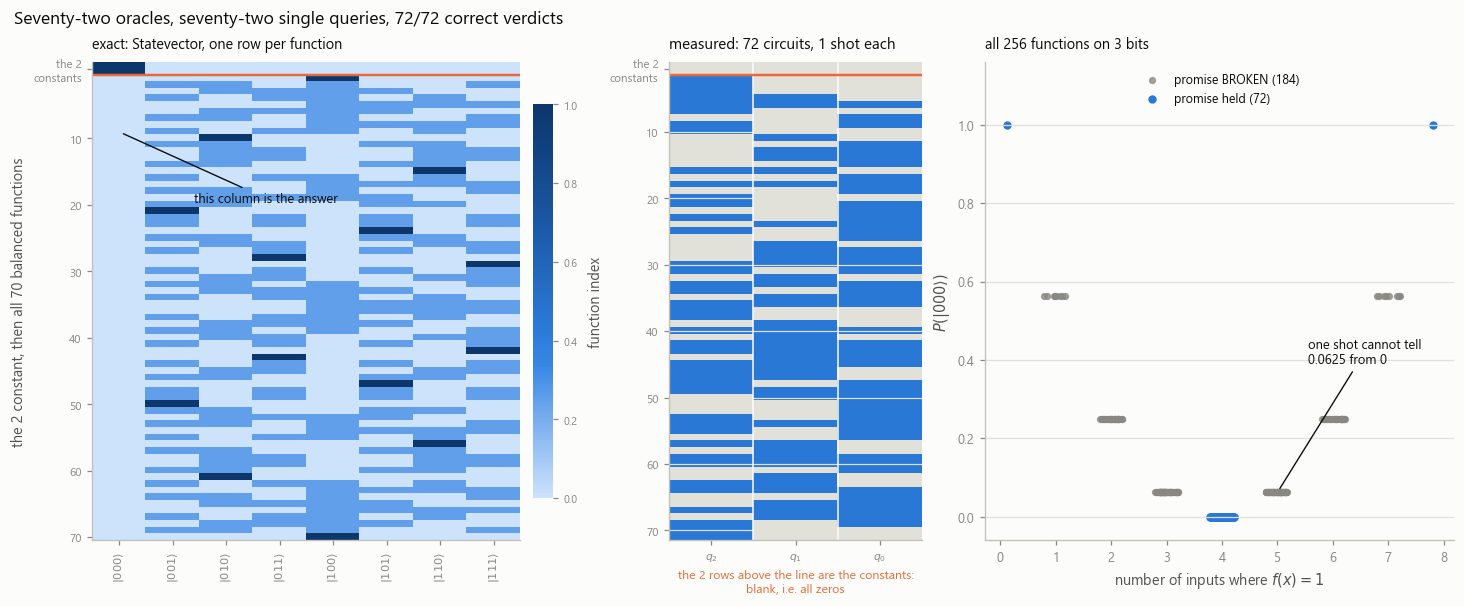

one-shot verdicts correct: 72/72
P(|000>) over the 70 balanced functions:  max = 6.066e-33 (float noise, not physics)
P(|000>) over the 2 constant functions :  min = 0.999999999999999
distinct P(|000>) over all 256 functions: [0.     0.0625 0.25   0.5625 1.    ]


In [6]:
def f_from_mask(mask):
    return lambda x, m=mask: int(m[x])


const_masks = [np.zeros(DIM_DJ, dtype=int), np.ones(DIM_DJ, dtype=int)]
balanced_masks = []
for ones in combinations(range(DIM_DJ), DIM_DJ // 2):
    m = np.zeros(DIM_DJ, dtype=int)
    m[list(ones)] = 1
    balanced_masks.append(m)
promised = const_masks + balanced_masks

# --- exact distributions, from Statevector on the n-qubit phase-oracle circuit
probs = np.array([np.abs(dj_stages_qk(
    phase_oracle_circuit(f_from_mask(m), N_DJ), N_DJ)[3]) ** 2
    for m in promised])

# --- ONE SHOT each, on the (n+1)-qubit circuit a machine would run
one_shot = run_counts([dj_measured(xor_oracle_circuit(f_from_mask(m), N_DJ), N_DJ)
                       for m in promised], 1, SEED)
shot_str = [next(iter(c)) for c in one_shot]
shot_bits = np.array([[int(ch) for ch in s] for s in shot_str])   # col 0 = q2
verdict = ["constant" if s == "0" * N_DJ else "balanced" for s in shot_str]
truth = ["constant"] * 2 + ["balanced"] * len(balanced_masks)
n_right = sum(v == t for v, t in zip(verdict, truth))

# --- all 256 functions, promise or not (statevector, no sampling)
all_masks = [np.array([(k >> b) & 1 for b in range(DIM_DJ)], dtype=int)
             for k in range(2 ** DIM_DJ)]
p0_all = np.array([abs(Statevector(dj_prefix(
    phase_oracle_circuit(f_from_mask(m), N_DJ), N_DJ, 3)).data[0]) ** 2
    for m in all_masks])
n_ones = np.array([int(m.sum()) for m in all_masks])

fig = plt.figure(figsize=(13.2, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 0.62, 1.15])

ax0 = fig.add_subplot(gs[0, 0])
im = ax0.imshow(probs, cmap=style.SEQ, vmin=0, vmax=1, aspect="auto",
                interpolation="nearest")
ax0.axhline(1.5, color=style.ORANGE, lw=1.6)
ax0.set_xticks(range(DIM_DJ))
ax0.set_xticklabels([grid.ket(label(i, N_DJ)) for i in range(DIM_DJ)],
                    fontsize=7.5, rotation=90)
ax0.set_yticks([0.5, 11, 21, 31, 41, 51, 61, 71])
ax0.set_yticklabels(["the 2\nconstants", "10", "20", "30", "40", "50", "60", "70"],
                    fontsize=7.5)
ax0.set_ylabel("the 2 constant, then all 70 balanced functions")
ax0.grid(False)
cb = fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
ax0.set_title("exact: Statevector, one row per function", loc="left", fontsize=9.5)
grid.annotate(ax0, "this column is the answer", xy=(0.0, 10.0),
              xytext=(1.4, 20.0), color=style.INK)

ax1 = fig.add_subplot(gs[0, 1])
grid.bit_record(ax1, shot_bits, col_labels=["$q_2$", "$q_1$", "$q_0$"],
                row_every=10, ylabel="function index",
                title="measured: 72 circuits, 1 shot each")
ax1.axhline(1.5, color=style.ORANGE, lw=1.6)
# Row 0 and 1 are two pixels tall out of 72; they need a tick to be findable,
# and the note goes under the axis, not above it where the title already is.
ax1.set_yticks([0.5, 10, 20, 30, 40, 50, 60, 70])
ax1.set_yticklabels(["the 2\nconstants", "10", "20", "30", "40", "50", "60",
                     "70"], fontsize=7.5)
ax1.set_xlabel("the 2 rows above the line are the constants:\nblank, i.e. all "
               "zeros", fontsize=8, color=style.ORANGE)

ax2 = fig.add_subplot(gs[0, 2])
jit = rng.uniform(-0.22, 0.22, size=len(p0_all))
inside = np.isin(n_ones, [0, DIM_DJ, DIM_DJ // 2])
ax2.scatter(n_ones[~inside] + jit[~inside], p0_all[~inside], s=14,
            color=style.MUTED, alpha=0.75, label="promise BROKEN (184)")
ax2.scatter(n_ones[inside] + jit[inside], p0_all[inside], s=20,
            color=style.BLUE, label="promise held (72)")
ax2.set_xticks(range(DIM_DJ + 1))
ax2.set_xlabel("number of inputs where $f(x) = 1$")
ax2.set_ylabel(r"$P(|000\rangle)$")
ax2.set_ylim(-0.06, 1.16)
ax2.legend(loc="upper center", ncols=1, fontsize=8.2)
ax2.set_title("all 256 functions on 3 bits", loc="left", fontsize=9.5)
grid.annotate(ax2, "one shot cannot tell\n0.0625 from 0", xy=(5.0, 0.0625),
              xytext=(5.55, 0.42), color=style.INK)

fig.suptitle("Seventy-two oracles, seventy-two single queries, "
             f"{n_right}/72 correct verdicts", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"one-shot verdicts correct: {n_right}/72")
print("P(|000>) over the 70 balanced functions:  max =",
      f"{probs[2:, 0].max():.3e}", "(float noise, not physics)")
print("P(|000>) over the 2 constant functions :  min =",
      f"{probs[:2, 0].min():.15f}")
print("distinct P(|000>) over all 256 functions:",
      np.round(np.unique(np.round(p0_all, 12)), 4))

$10^{-33}$ is not a small probability, it is the size of a rounding error in
double precision — and Aer sampled from it 70 times without ever landing on
`000`.

The right panel is the one to remember. $P(|000\rangle)$ is a *continuous* measure
of how unbalanced $f$ is; the promise is what turns it into a yes/no answer.
Deutsch–Jozsa does not detect "constant". It measures the average sign, and the
promise guarantees that number is $\pm1$ or $0$ and nothing in between.

---

## Part 2 — Bernstein–Vazirani: the same circuit, a better question

Restrict the oracle to $f_s(x) = s \cdot x \bmod 2$ for a hidden $n$-bit $s$.

**Classically this costs exactly $n$ queries** and no fewer: ask $f_s(2^q)$ for
each $q$ and read off $s_q$. Each query returns one bit and the secret is $n$
bits, so $n$ is optimal by information counting — there is nothing clever to do.
The cell below implements that classical attack with a *counter wrapped around the
oracle*, so the query count is measured rather than asserted.

**Quantum: one query, always.** The same circuit as Deutsch–Jozsa. The final
amplitude on outcome $y$ is

$$\frac{1}{2^n}\sum_x (-1)^{s\cdot x + x\cdot y}
= \frac{1}{2^n}\sum_x (-1)^{x\cdot(s\oplus y)}
= \begin{cases}1 & y = s\\ 0 & \text{otherwise,}\end{cases}$$

because $\sum_x (-1)^{x\cdot m}$ is $2^n$ for $m=0$ and $0$ for every non-zero
mask. The final state is *exactly* $|s\rangle$, so one shot hands you the whole
secret.

$f_s$ is balanced for every $s \neq 0$ and constant for $s = 0$, so BV's oracles
are a subset of DJ's. Same circuit, same one query — we are simply reading the
*whole* output register instead of asking one yes/no question about it.

In [7]:
class CountingOracle:
    """f_s with a call counter -- the classical query cost, measured."""

    def __init__(self, s):
        self.s = s
        self.calls = 0

    def __call__(self, x):
        self.calls += 1
        return parity(self.s & x)


def classical_bv(oracle, n):
    """Ask for one basis vector at a time. n queries, exactly."""
    return sum(oracle(1 << q) << q for q in range(n))


SECRET = 0b1011
oracle = CountingOracle(SECRET)
assert classical_bv(oracle, N_BITS) == SECRET
print(f"classical BV recovered |{label(SECRET, N_BITS)}> "
      f"in {oracle.calls} oracle calls")

bv_stages = dj_stages_qk(bv_phase_circuit(SECRET, N_BITS), N_BITS)
bv_counts = run_counts([dj_measured(bv_xor_circuit(SECRET, N_BITS), N_BITS)],
                       1, SEED)[0]
shot = next(iter(bv_counts))
print(f"quantum  BV recovered |{shot}> in 1 oracle call "
      f"(1 circuit, shots=1)")
print(f"exact P(|{label(SECRET, N_BITS)}>) = "
      f"{abs(bv_stages[3][SECRET]) ** 2:.15f}")
print("\nfinal state:", grid.show_state(bv_stages[3]), sep="\n")

# The Walsh-Hadamard identity the derivation used, checked against Qiskit's own
# Operator for the H layer.
for n in range(1, 6):
    qc = QuantumCircuit(n)
    qc.h(list(range(n)))
    want = np.array([[(-1.0) ** parity(x & y) for x in range(2 ** n)]
                     for y in range(2 ** n)]) / np.sqrt(2 ** n)
    assert np.allclose(Operator(qc).data, want), n
print("\nH^(x)n [y,x] == (-1)^(x.y)/sqrt(2^n)   verified against Operator, n = 1..5")

classical BV recovered |1011> in 4 oracle calls


quantum  BV recovered |1011> in 1 oracle call (1 circuit, shots=1)
exact P(|1011>) = 0.999999999999999

final state:
  |1011>  +1.0000+0.0000j

H^(x)n [y,x] == (-1)^(x.y)/sqrt(2^n)   verified against Operator, n = 1..5


## Figure 4 — one secret, four stages, and the circuit that did it

Top: the whole 5-qubit circuit, drawn as Qiskit draws it — ancilla prepared in
$|-\rangle$, Hadamard layer, three `cx` gates that *are* the oracle, Hadamard
layer, measure. Left of the barrier there is nothing secret; between the barriers
is the entire black box.

Bottom: the filmstrip on the 4 input qubits. The third panel is the one to stare
at — all sixteen bars the same height, the register looking *completely uniform*,
and every bit of the secret sitting in the pattern of colour. Measure there and
you get a uniformly random 4-bit string, sixteen times out of sixteen useless.

Then one Hadamard layer, and all of it lands on a single bar.

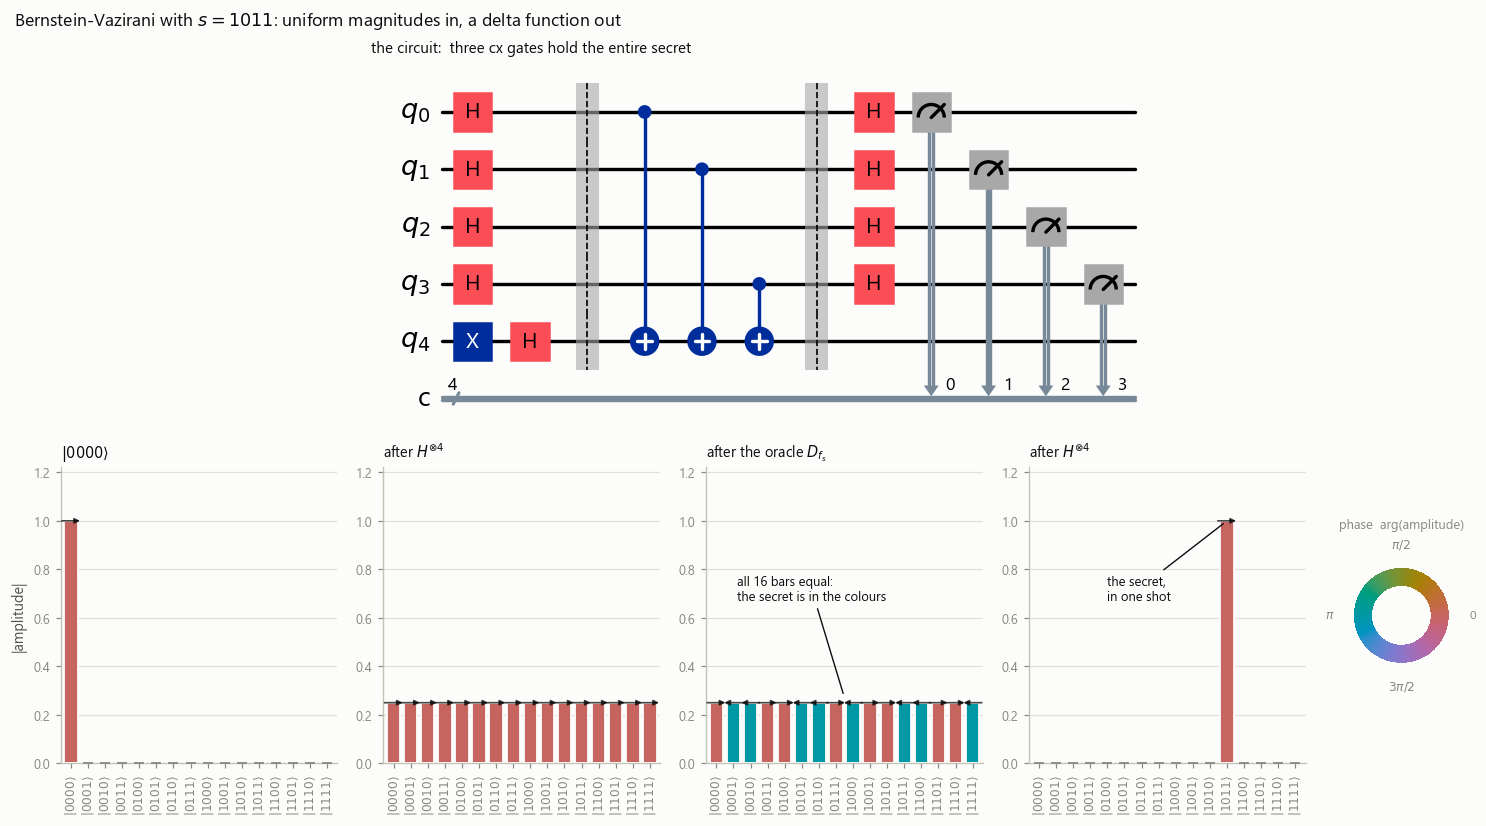

amplitude on the secret: +0.999999999999999
largest other amplitude : 2.362e-17


In [8]:
titles = [r"$|0000\rangle$", r"after $H^{\otimes 4}$",
          r"after the oracle $D_{f_s}$", r"after $H^{\otimes 4}$"]

# The circuit drawer preserves its own aspect, so the top row has to be TALL
# for the drawing to come out wide. Too short a row and it shrinks to a stamp.
fig = plt.figure(figsize=(13.4, 7.4))
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 0.36],
                      height_ratios=[1.55, 1.25])

axc = fig.add_subplot(gs[0, :])
dj_measured(bv_xor_circuit(SECRET, N_BITS), N_BITS).draw(
    "mpl", ax=axc, style={"backgroundcolor": style.SURFACE}, fold=-1)
axc.set_title("the circuit:  three cx gates hold the entire secret",
              loc="left", fontsize=10)

for c, (vec, t) in enumerate(zip(bv_stages, titles)):
    ax = fig.add_subplot(gs[1, c])
    grid.amp_bars(ax, vec, ylim=1.22, label_rotation=90)
    ax.set_title(t, loc="left", fontsize=9.5, pad=7)
    if c:
        ax.set_ylabel("")

grid.annotate(fig.axes[3], "all 16 bars equal:\nthe secret is in the colours",
              xy=(7.5, 0.27), xytext=(1.2, 0.72), color=style.INK)
grid.annotate(fig.axes[4], "the secret,\nin one shot", xy=(SECRET, 1.0),
              xytext=(4.0, 0.72), color=style.INK)

axw = fig.add_subplot(gs[1, 4], projection="polar")
style.phase_wheel(axw)
fig.suptitle(r"Bernstein-Vazirani with $s = 1011$: uniform magnitudes in, "
             "a delta function out", x=0.005, ha="left", fontsize=11.5)
plt.show()

print("amplitude on the secret:", f"{bv_stages[3][SECRET].real:+.15f}")
print("largest other amplitude :",
      f"{np.max(np.abs(np.delete(bv_stages[3], SECRET))):.3e}")

## Figure 5 — all sixteen secrets, one query each

Sixteen secrets, sixteen circuits, `shots=1` on every one of them. Sixteen oracle
calls total, against the $16 \times 4 = 64$ a classical attack needs.

Left: the true secrets as bits. Middle: what a single `SamplerV2` shot returned.
Right: their XOR — the errors — which is blank. Far right: the full
$16\times16$ matrix of $P(\text{outcome}\mid s)$ from `Statevector`, a perfect
identity.

There is no averaging and no majority vote anywhere in this figure. One sample
from each of sixteen states reconstructs sixteen secrets, because each of those
states *is* a basis state.

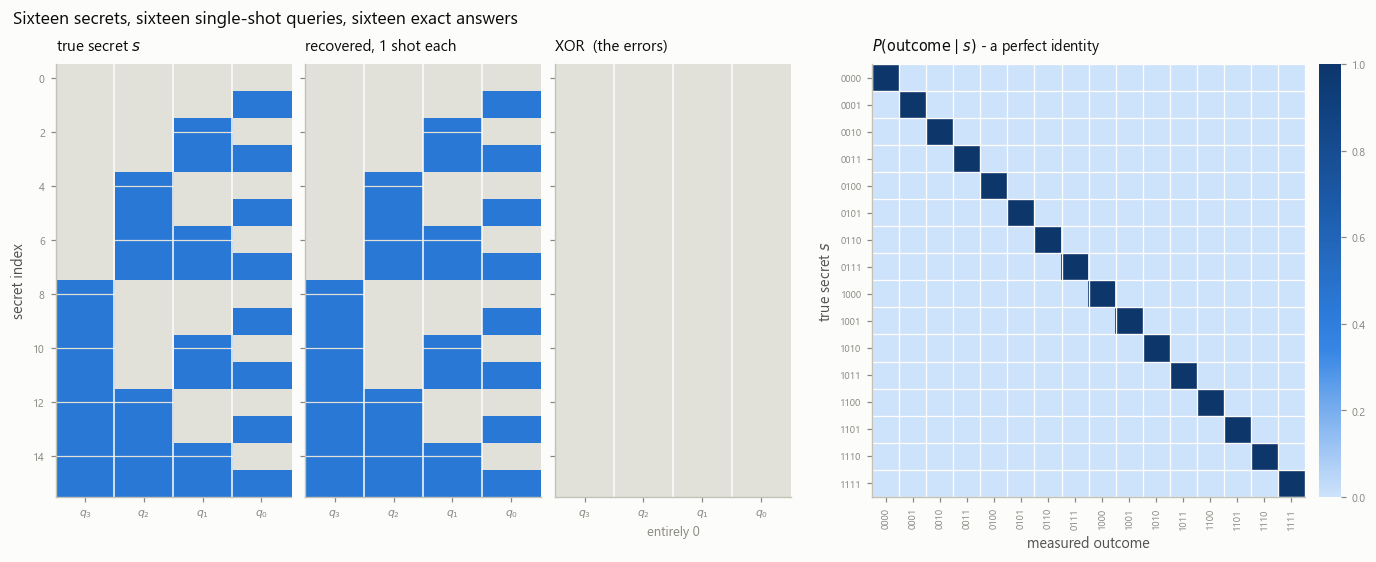

all 16 secrets recovered exactly? True
smallest diagonal probability   : 0.999999999999999
largest off-diagonal probability: 5.577e-34

classical oracle calls for these 16 secrets: 64   quantum: 16


In [9]:
secrets = np.arange(N_IN)
bv_circuits = [dj_measured(bv_xor_circuit(s, N_BITS), N_BITS) for s in secrets]
bv_shots = run_counts(bv_circuits, 1, SEED + 1)
recovered_all = np.array([int(next(iter(c)), 2) for c in bv_shots])

prob_matrix = np.array([np.abs(dj_stages_qk(bv_phase_circuit(s, N_BITS),
                                            N_BITS)[3]) ** 2 for s in secrets])


def bit_image(values):
    """Column j is qubit 3-j, so each row reads like the printed label."""
    return np.array([[bit(v, N_BITS - 1 - j) for j in range(N_BITS)]
                     for v in values])


true_img = bit_image(secrets)
rec_img = bit_image(recovered_all)
BIT_LABELS = ["$q_3$", "$q_2$", "$q_1$", "$q_0$"]

fig = plt.figure(figsize=(12.4, 5.0))
gs = fig.add_gridspec(1, 4, width_ratios=[0.55, 0.55, 0.55, 1.12])

for k, (img, t) in enumerate([(true_img, "true secret $s$"),
                              (rec_img, "recovered, 1 shot each"),
                              (true_img ^ rec_img, "XOR  (the errors)")]):
    ax = fig.add_subplot(gs[0, k])
    grid.bit_record(ax, img, col_labels=BIT_LABELS, row_every=2,
                    ylabel="secret index" if k == 0 else "", title=t)
    if k:
        ax.set_yticklabels([])
fig.axes[2].set_xlabel("entirely 0", fontsize=8.5, color=style.MUTED)

axm = fig.add_subplot(gs[0, 3])
im = axm.imshow(prob_matrix, cmap=style.SEQ, vmin=0, vmax=1,
                interpolation="nearest")
axm.set_xticks(range(N_IN)); axm.set_yticks(range(N_IN))
axm.set_xticklabels([label(i, N_BITS) for i in range(N_IN)], fontsize=6.5,
                    rotation=90)
axm.set_yticklabels([label(i, N_BITS) for i in range(N_IN)], fontsize=6.5)
axm.set_xticks(np.arange(-0.5, N_IN, 1), minor=True)
axm.set_yticks(np.arange(-0.5, N_IN, 1), minor=True)
axm.grid(which="minor", color=style.SURFACE, linewidth=0.9)
axm.grid(which="major", visible=False)
axm.tick_params(which="minor", length=0)
axm.set_xlabel("measured outcome")
axm.set_ylabel("true secret $s$")
axm.set_title(r"$P(\mathrm{outcome} \mid s)$ - a perfect identity", loc="left",
              fontsize=9.5)
cb = fig.colorbar(im, ax=axm, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)

fig.suptitle("Sixteen secrets, sixteen single-shot queries, sixteen exact answers",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("all 16 secrets recovered exactly?",
      bool(np.array_equal(recovered_all, secrets)))
print("smallest diagonal probability   :",
      f"{np.min(np.diag(prob_matrix)):.15f}")
print("largest off-diagonal probability:",
      f"{np.max(prob_matrix - np.diag(np.diag(prob_matrix))):.3e}")

total_classical = 0
for s in secrets:
    o = CountingOracle(s)
    assert classical_bv(o, N_BITS) == s
    total_classical += o.calls
print(f"\nclassical oracle calls for these 16 secrets: {total_classical}"
      f"   quantum: {N_IN}")

Sixty-four classical queries against sixteen quantum ones, both counted rather
than quoted. A factor of four at $n=4$ — real, provable, and *linear*.

Which brings us to the part every tutorial skips.

## Figure 6 — one query, and what the query costs

**Left panel** — the plot everyone shows. Deterministic worst-case classical
queries against a flat quantum line at 1. It is a true statement about
*deterministic, exact* classical algorithms in the *query* model.

A09's Figure 6 spent itself on the first honest correction: allow the classical
algorithm to be randomized and wrong one time in a million, and Deutsch–Jozsa's
exponential separation collapses to about **20 queries for any $n$**. That
argument is not repeated here; go read it. Bernstein–Vazirani survives it — $n$
versus 1 is tight, because each classical query returns one bit and the secret is
$n$ bits.

**Right panel** — the correction the SDK makes possible, and the reason this
notebook exists. Query complexity counts *queries*. It says nothing about what
one query costs. So `transpile()` the oracles down to a hardware-like basis
(`cx`, `rz`, `sx`, `x`) and count the two-qubit gates:

- **Bernstein–Vazirani, worst case $s = 11\ldots1$**: $n$ `cx` gates. Linear.
  This algorithm is genuinely cheap.
- **A generic balanced $f$ given as a truth table**: one multi-controlled block
  per input where $f=1$, so $2^{n-1}$ blocks, each of which decomposes into
  $O(n)$ two-qubit gates. **Exponential.**

The dashed line is the classical query count. The generic oracle's *gate* count
grows at the same rate as the classical *query* count it was supposed to beat.
The speedup did not vanish — it moved, out of the query count and into the box.

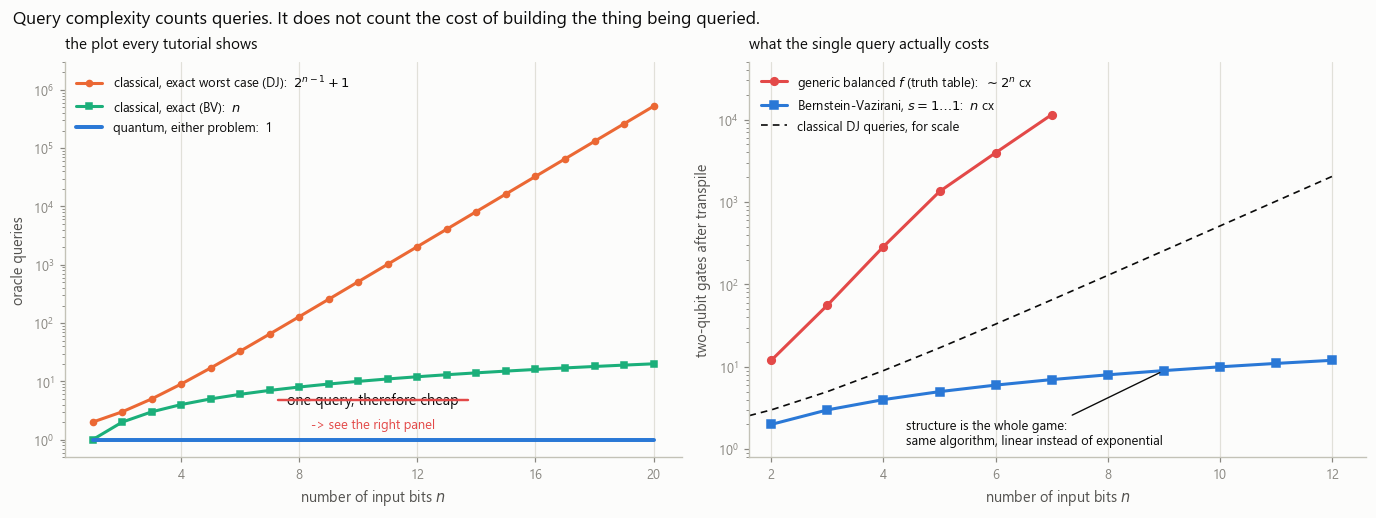

  n   BV cx  BV depth  generic cx  generic depth
  2       2         2          12             24
  3       3         3          56            110
  4       4         4         288            613
  5       5         5        1344           2592
  6       6         6        3968           6535
  7       7         7       11520          18246
  8       8         8           -              -
  9       9         9           -              -
 10      10        10           -              -
 11      11        11           -              -
 12      12        12           -              -


In [10]:
HW_BASIS = ["cx", "rz", "sx", "x"]


def two_qubit_gates(qc):
    """cx count after transpiling to a hardware-like basis, all-to-all coupling."""
    t = transpile(qc, basis_gates=HW_BASIS, optimization_level=1,
                  seed_transpiler=SEED)
    return t.count_ops().get("cx", 0), t.depth()


ns_bv = np.arange(2, 13)
bv_cx, bv_depth = [], []
for n in ns_bv:
    c, d = two_qubit_gates(bv_xor_circuit(2 ** n - 1, n))     # worst case s = 1..1
    bv_cx.append(c); bv_depth.append(d)

ns_gen = np.arange(2, 8)
gen_cx, gen_depth = [], []
for n in ns_gen:
    mask = np.zeros(2 ** n, dtype=int)
    mask[rng.permutation(2 ** n)[: 2 ** (n - 1)]] = 1        # a random balanced f
    c, d = two_qubit_gates(xor_oracle_circuit(f_from_mask(mask), n))
    gen_cx.append(c); gen_depth.append(d)

ns = np.arange(1, 21)
classical_dj = 2 ** (ns - 1) + 1

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))

ax = axes[0]
ax.semilogy(ns, classical_dj, color=style.ORANGE, marker="o", ms=4,
            label="classical, exact worst case (DJ):  $2^{n-1}+1$")
ax.semilogy(ns, ns.astype(float), color=style.AQUA, marker="s", ms=4,
            label="classical, exact (BV):  $n$")
ax.semilogy(ns, np.ones_like(ns), color=style.BLUE, lw=2.6,
            label="quantum, either problem:  1")
ax.set_xlabel("number of input bits $n$")
ax.set_ylabel("oracle queries")
ax.set_xticks(range(0, 21, 4))
ax.set_ylim(0.5, 3e6)
ax.grid(axis="both")
ax.legend(loc="upper left", fontsize=8.5)
ax.set_title("the plot every tutorial shows", loc="left", fontsize=10)
claim = ax.text(10.5, 4.0, "one query, therefore cheap", fontsize=9.5,
                color=style.INK, ha="center")
grid.strike(ax, claim)
ax.text(10.5, 1.6, "-> see the right panel", fontsize=8.5, color=style.RED,
        ha="center")

ax = axes[1]
ax.semilogy(ns_gen, gen_cx, color=style.RED, marker="o", ms=5,
            label=r"generic balanced $f$ (truth table):  $\sim 2^{n}$ cx")
ax.semilogy(ns_bv, bv_cx, color=style.BLUE, marker="s", ms=5,
            label=r"Bernstein-Vazirani, $s = 1\ldots1$:  $n$ cx")
ax.semilogy(ns[:12], classical_dj[:12], color=style.INK, lw=1.1, ls=(0, (4, 3)),
            label="classical DJ queries, for scale")
ax.set_xlabel("number of input bits $n$")
ax.set_ylabel("two-qubit gates after transpile")
ax.set_xticks(range(2, 13, 2))
ax.set_xlim(1.6, 12.6)
ax.set_ylim(0.8, 5e4)          # headroom: the n=7 marker sat on the top spine
ax.grid(axis="both")
ax.legend(loc="upper left", fontsize=8.5)
ax.set_title("what the single query actually costs", loc="left", fontsize=10)
grid.annotate(ax, "structure is the whole game:\nsame algorithm, "
              "linear instead of exponential", xy=(9.0, bv_cx[7]),
              xytext=(4.4, 1.55), color=style.INK)

fig.suptitle("Query complexity counts queries. It does not count the cost of "
             "building the thing being queried.", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print(f"{'n':>3} {'BV cx':>7} {'BV depth':>9} {'generic cx':>11} "
      f"{'generic depth':>14}")
for k, n in enumerate(ns_bv):
    g = f"{gen_cx[k]:>11}" if n in ns_gen else f"{'-':>11}"
    gd = f"{gen_depth[k]:>14}" if n in ns_gen else f"{'-':>14}"
    print(f"{n:>3} {bv_cx[k]:>7} {bv_depth[k]:>9} {g} {gd}")

Read the two curves in the right panel against each other. Same algorithm, same
one query, same circuit *shape* — and the gate count is linear in one case and
exponential in the other. The difference is not quantum mechanics. It is whether
you were handed a function with structure or a lookup table.

That is the honest summary of this family of algorithms: **they extract structure
you were already promised existed.** Bernstein–Vazirani is fast because $s\cdot x$
is a cheap circuit. Deutsch–Jozsa is fast on the oracles that are cheap to build
and useless on the ones that are not.

---

## Honest limits

**The oracle already contains the answer.** To *build* the BV oracle you must know
$s$ — Figure 4's three `cx` gates are placed by reading the secret's bits. The
algorithm is a statement about how efficiently information can be extracted from a
box someone else built, not a way to discover something nobody knows. Every
"$O(1)$ vs $O(2^n)$" headline in this family rests on that framing.

**The generic oracle construction is itself $2^n$ classical queries.**
`phase_oracle_circuit` and `xor_oracle_circuit` both loop over every input and
call `f` on it. If you had to do that, you would already have the answer.

**The promise is doing enormous work.** Figure 3's right panel: off the promise,
$P(|000\rangle)$ is a continuous measure of imbalance and one shot tells you very
little. There is no "approximate Deutsch–Jozsa" that degrades gracefully; the
algorithm's exactness *is* the promise.

**Randomization eats DJ's speedup.** A09 Figure 6 draws it: twenty random
classical queries give six nines of confidence for any $n$. The exponential
separation is against *deterministic exact* classical algorithms only. BV's linear
separation survives; DJ's exponential one essentially does not.

**Everything here is noiseless.** `AerSimulator` with no noise model, exact gates,
perfect readout. The final BV state is exactly $|s\rangle$, so `shots=1` is
enough. Give each `cx` a $10^{-3}$ error rate and the single-shot readout becomes
a majority vote over many shots — and the query count you were bragging about goes
up by that factor. B26 and C27 take noise seriously; this notebook does not.

**`transpile()` here is optimistic too.** We used `basis_gates` with **no coupling
map**, i.e. all-to-all connectivity. On a real device with a fixed lattice, the
`mcx` decompositions in the generic oracle acquire swap networks and the red curve
in Figure 6 gets worse, not better. The BV oracle's `cx(q, n)` gates all target the
same ancilla, which is a star topology no real chip has either.

**The filmstrip draws something you can never see.** Columns 1–3 of Figures 2 and
4 are `Statevector` output — a full complex vector read out of a classical
simulator. A real run gives you *one bitstring* from the last column and nothing
whatsoever from the others. Column 3 is exactly as instructive and as misleading
as it looks: the information is visibly there, and visibly unreadable.

**Amplitude bars stop scaling immediately.** Sixteen bars already needs rotated
labels. Deutsch–Jozsa on 20 qubits — a routine size — cannot be drawn this way at
all. A07 confronts that wall.

## Checkpoint

Track B notebooks close by asserting against a from-scratch Track A computation.
Here that means rebuilding A09's `phase_oracle`, `xor_oracle` and `dj_stages` in
raw NumPy — no `qiskit.quantum_info` anywhere in the block — and demanding that
every statevector Qiskit produced matches, amplitude for amplitude.

In [11]:
# ---------------------------------------------------------------- Track A
# A09's helpers, verbatim in spirit: diagonal phase oracle, permutation XOR
# oracle, and the four-stage run. Raw NumPy only.
def phase_oracle_np(f, n):
    return np.diag([(-1.0) ** f(x) for x in range(2 ** n)]).astype(complex)


def xor_oracle_np(f, n):
    dim = 2 ** (n + 1)
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        x, y = i & (2 ** n - 1), (i >> n) & 1
        M[x | ((y ^ f(x)) << n), i] = 1.0
    return M


def dj_stages_np(f, n):
    Hn = hadamard_all_np(n)
    v0 = np.zeros(2 ** n, dtype=complex); v0[0] = 1.0
    v1 = Hn @ v0
    v2 = phase_oracle_np(f, n) @ v1
    return [v0, v1, v2, Hn @ v2]


# 1. THE cross-track assertion: A09's statevectors == Qiskit's, every stage.
for f in (f_const, f_bal, bv_f(0b101), lambda x: (x * x + 1) % 2):
    a09 = dj_stages_np(f, N_DJ)
    b21 = dj_stages_qk(phase_oracle_circuit(f, N_DJ), N_DJ)
    for va, vb in zip(a09, b21):
        assert np.allclose(va, vb), (va, vb)

# ...and for BV on 1..4 qubits, every secret, both oracle constructions.
for n in range(1, 5):
    for s in range(2 ** n):
        a09 = dj_stages_np(bv_f(s), n)[3]
        assert np.allclose(a09, dj_stages_qk(bv_phase_circuit(s, n), n)[3])
        assert np.allclose(a09, dj_stages_qk(
            phase_oracle_circuit(bv_f(s), n), n)[3])

# 2. The oracle CIRCUITS equal A09's oracle MATRICES, both forms.
for n in (2, 3):
    for trial in range(6):
        mask = rng.integers(0, 2, size=2 ** n)
        f = f_from_mask(mask)
        D = Operator(phase_oracle_circuit(f, n)).data
        U = Operator(xor_oracle_circuit(f, n)).data
        assert np.allclose(D, phase_oracle_np(f, n))
        assert np.allclose(U, xor_oracle_np(f, n))
        assert np.allclose(D @ D, np.eye(2 ** n))               # involutive
        assert np.allclose(U @ U, np.eye(2 ** (n + 1)))
        assert np.allclose(np.diag(np.diag(D)), D)              # genuinely diagonal
        assert set(np.round(np.diag(D).real, 9)) <= {1.0, -1.0}
        # phase kickback, as a matrix identity, exactly as A09 asserted it
        psi = rng.normal(size=2 ** n) + 1j * rng.normal(size=2 ** n)
        psi /= np.linalg.norm(psi)
        assert np.allclose(U @ np.kron(MINUS, psi), np.kron(MINUS, D @ psi))

# 3. The display circuits in Figure 1 are the unitaries they claim to be,
#    including the two constants (identity and a bare global phase).
assert np.allclose(Operator(const0_phase).data, np.eye(N_IN))
assert np.allclose(Operator(const1_phase).data, -np.eye(N_IN))
assert np.allclose(Operator(const1_phase).data,
                   Operator(phase_oracle_circuit(lambda x: 1, N_BITS)).data)
assert np.allclose(Operator(const1_xor).data,
                   xor_oracle_np(lambda x: 1, N_BITS))

# 4. Endianness: qubit 0 is the RIGHTMOST label character, in both tracks.
qx = QuantumCircuit(3)
qx.x(0)
assert int(np.argmax(np.abs(Statevector(qx).data))) == 1
for n in (2, 3, 4):
    for i in range(2 ** n):
        assert label(i, n) == "".join(str(bit(i, q)) for q in reversed(range(n)))
assert np.allclose(np.diag(Operator(bv_phase_circuit(0b0001, 3)).data).real,
                   [(-1.0) ** bit(x, 0) for x in range(8)])

# 5. CONSTANT -> all amplitude on |0...0>; BALANCED -> exactly none, for all 70.
for n in (2, 3, 4):
    for c in (0, 1):
        v = dj_stages_qk(phase_oracle_circuit(lambda x, c=c: c, n), n)[3]
        assert np.isclose(abs(v[0]), 1.0)
        assert np.allclose(v[1:], 0.0, atol=1e-12)
assert np.allclose(probs[:2, 0], 1.0)
assert np.all(probs[2:, 0] < 1e-12)

# 6. The intermediate state is unreadable: after the oracle every probability is
#    exactly 1/2^n, constant and balanced alike.
for f in (f_const, f_bal):
    p = np.abs(dj_stages_qk(phase_oracle_circuit(f, N_DJ), N_DJ)[2]) ** 2
    assert np.allclose(p, 1.0 / DIM_DJ)

# 7. The amplitude on |0...0> is the average sign, exactly.
for m in (const_masks + balanced_masks[:20]):
    f = f_from_mask(m)
    want = sum((-1) ** f(x) for x in range(DIM_DJ)) / DIM_DJ
    assert np.isclose(dj_stages_qk(phase_oracle_circuit(f, N_DJ), N_DJ)[3][0].real,
                      want)

# 8. Off the promise, P(|0..0>) = (k/(N/2) - 1)^2 -- computed from Qiskit
#    circuits, matched against the closed form A09 derived.
for m, k, p in zip(all_masks, n_ones, p0_all):
    assert np.isclose(p, (k / (DIM_DJ / 2) - 1.0) ** 2)

# 9. The MEASURED results: 72 single-shot DJ verdicts and 16 single-shot BV
#    secrets, all correct. These come from SamplerV2, not from algebra.
assert n_right == 72
assert shot_str[0] == "0" * N_DJ and shot_str[1] == "0" * N_DJ
assert all(s != "0" * N_DJ for s in shot_str[2:])
assert np.array_equal(recovered_all, secrets)
assert np.array_equal(true_img ^ rec_img, np.zeros_like(true_img))
assert np.allclose(prob_matrix, np.eye(N_IN), atol=1e-12)
assert int(shot, 2) == SECRET

# 10. Query counting, measured rather than quoted: n classical calls per secret.
for n in (3, 4, 5):
    for s in (0, 1, 2 ** n - 1, 2 ** (n - 1)):
        o = CountingOracle(s)
        assert classical_bv(o, n) == s
        assert o.calls == n
assert total_classical == N_IN * N_BITS == 64

# 11. Circuit cost: the BV oracle is linear in n, the generic one is not.
assert bv_cx == list(ns_bv)                       # one cx per set bit of s
assert gen_cx[-1] > 20 * gen_cx[0]                # exponential blow-up
assert all(b >= a for a, b in zip(gen_cx, gen_cx[1:]))

print("B21 checkpoint passed.")
print(f"  A09 (NumPy) and B21 (Qiskit) statevectors agree to "
      f"{np.max(np.abs(dj_stages_np(f_bal, N_DJ)[3] - dj_stages_qk(phase_oracle_circuit(f_bal, N_DJ), N_DJ)[3])):.2e}")
print(f"  72/72 single-shot DJ verdicts correct, "
      f"{int(np.sum(recovered_all == secrets))}/16 BV secrets recovered")

B21 checkpoint passed.
  A09 (NumPy) and B21 (Qiskit) statevectors agree to 5.61e-17
  72/72 single-shot DJ verdicts correct, 16/16 BV secrets recovered


---

**Next:** [B22 — Grover in Qiskit](B22_Grover_Qiskit.ipynb). Deutsch–Jozsa and
Bernstein–Vazirani got exact answers from one query because the interference was
perfect — the promise made every wrong outcome cancel to identically zero. Grover
drops the promise entirely: *find the one input where $f(x)=1$*, with no structure
to exploit. One round of interference is no longer enough, the answer arrives with
a probability rather than a certainty, and repeating the round once too often
makes it worse.